### Logistic Regression Quick Recap

**What is Logistic Regression?**

It is a statistical method that we use for binary classification. We ask a question that has probably two answers, which is the general type but the answer number can change, and we find the probability of hıw much we can find the right answer of it. Instead of linear line we use a Sigmoid S shaped line, and the two tail of that line is 0 and 1.

* If probability is higher than 0.5 -> then it belongs to class 1, if not then it belongs to class 0 which is also known as default.

We have a few diagnostics and tests. First one is Goodnes-of-fit;

#### Goodnes of Fit Tests

**Hoshmer-Lemeshow Test** : It divides data into dozens and compares the actual number of models predicted number. If the p value is high then there is no significant difference between model and the real data.


**Likelihood Ratio Test (LRT)**  :It compares your model vs null model to see if the features are improving the fit.

**Wald Test** : It tests if an individual coef. is different than 0.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv("FakeNewsNet.csv")
df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [4]:
df.isnull().sum()

title              0
news_url         330
source_domain    330
tweet_num          0
real               0
dtype: int64

In [5]:
df.shape

(23196, 5)

In [6]:
#we have enough data, like 23k rows so we will drop the NaN's

df = df.dropna()
df.isnull().sum()

title            0
news_url         0
source_domain    0
tweet_num        0
real             0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22866 entries, 0 to 23195
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          22866 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   tweet_num      22866 non-null  int64 
 4   real           22866 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.0+ MB


Might be the source domain important for us because some of the new websites are all fake news and some of them are
good ones. We have to encode this and we can use onehot encoder for this. Tweet number may be a problem because fake
news has more possibility to wander around internet faster. So we have to take those into account before we start our analysis. A good analysis should always start in the mind.

In [8]:
df.loc[df['tweet_num'].idxmax()]

#highest tweet number here is the fake news. this was one thing that i was suspicious.

title                                      The Legislative Process
news_url         https://www.house.gov/content/learn/legislativ...
source_domain                                        www.house.gov
tweet_num                                                    29060
real                                                             0
Name: 11489, dtype: object

In [9]:
top_10_news= df.nlargest(10,"tweet_num")

print(top_10_news)

                                                   title  \
11489                            The Legislative Process   
21215       One in Four – Congressman Joe Pitts – Medium   
9505   Rep. Michael McCaul (R-TX) Appears on Face the...   
21088  Outlook, Office, Skype, Bing, Breaking News, a...   
3379                               interview on Fox News   
18042                                    Wake Up America   
7788     "One Hundred Percent" by Club for Growth Action   
13246  Carolyn B. Maloney on Twitter: "Women's health...   
3370                             LexisNexis(R) Publisher   
9675                      Democratic National Convention   

                                                news_url  \
11489  https://www.house.gov/content/learn/legislativ...   
21215  https://medium.com/@RepJoePitts/one-in-four-66...   
9505   http://us3.campaign-archive1.com/?u=468d5dc433...   
21088  http://www.msnbc.msn.com/id/32935603/ns/meet_t...   
3379   http://www.cq.com/doc/newsmakert

So here the top 10 most tweeted news has 8 real news, which is absolutely perfect. This means that high tweet numbers may have positive sign or higher probability to label a new that it is true. 

Another thing we should also look is the domain.

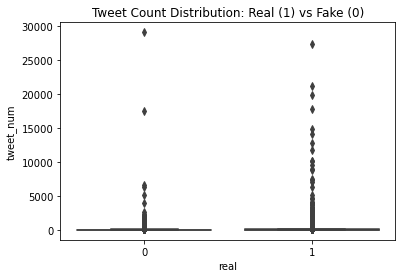

In [10]:
import seaborn as sns

# This will show you if the highest numbers belong mostly to fake news
sns.boxplot(x='real', y='tweet_num', data=df)
plt.title('Tweet Count Distribution: Real (1) vs Fake (0)')
plt.show()

In [11]:
# Its time to take a look at if domain is important or not; or has the same meaning as I mentioned before.
house_gov_stories = df[df['source_domain'] == 'www.house.gov']

print(house_gov_stories[['title', 'tweet_num', 'real']].head(20))

                         title  tweet_num  real
11489  The Legislative Process      29060     0


In [12]:
#house.gov has only 1 new and it was fake so i will take a look at facebook instead.

house_gov_stories = df[df['source_domain'] == 'www.facebook.com']

print(house_gov_stories[['title', 'tweet_num', 'real']].head(20))

                                                   title  tweet_num  real
410                         Vets for Trump Facebook page         35     0
1163                                          Sid Miller       1099     0
1586         The numbers don't lie... - Occupy Democrats          9     0
1871                                        Trump Nation       1369     0
5893   And we pay her a salary!.... - Judge Jeanine P...          4     0
6740   Peace Through Strength and American Pride vs. ...          0     1
18042                                    Wake Up America      17548     0
18621                        America's Enduring Strength          0     1


In [13]:
df["source_domain"].nunique()

2441

And **BINGO**, we can say facebook has a bad reputation here because almost all of it news are false. And I might thought about it. Because there is so much people here and everyone can write something out just for more tweets, likes and ticks. Now I need to convert objects to numbers but how?

Actually for source_domain variable i will use Target Encoding instead of One-Hot-Encoder because İ love my pc and i dont want to blow it out. There is like 2441 unique sources and using OneHotEncoder is not a good idea. Instead of this we will use, *by the way i say we but i am doing this project all by myself and i think imight have some problems but i have a job and i basically can not have me time most of the time and cant journal as i did before and i cant talk most of my friends and my conversations are like so surface level with my colleagues and actually i wanna go back to lithuania but so whatever*, **Target Encoding**: its main aim is to find the probability of the source being real news or not.I will use only one column instead of hundereds of them with OneHotEncoder. We will also use parameters like M-estimate and Smoothing to avoid extreme values like 1 or 0.

Second part is **encoding the title with Natural Language Processing (NLP)**; We will find some of the expressions like BREAKING or SHOCKING which are associated with fake news. It creates numerical weight for all of the words and the model will assign such words with negative coefficient.But we need a constraint to avoid explosion of logical regression and it is max_features.

The third and last part is encoding the News Url. All URLs are unique but we can understand if a news is fake by looking at the URL because some URLs look like they are for real but in reality those are just the imitation of the real website, only this one has like more symbols like - or dots. Fake news might have long urls due to this reason. Or it might have random numbers.Does the url starts with https or http? Those are important.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('domain_enc', TargetEncoder(), ['source_domain']),
        ('title_tfidf', TfidfVectorizer(max_features=500), 'title'),
        ('num_scaler', StandardScaler(), ['tweet_num'])
    ])


y = df["real"]
X = df.drop(columns=["real"],axis =0)
#X_transformed = preprocessor.fit_transform(X, y)

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

X_train_transformed = preprocessor.fit_transform(X_train,y_train)

X_test_transformed = preprocessor.transform(X_test)

model = LogisticRegression()

model.fit(X_train_transformed,y_train)


LogisticRegression()

In [16]:
from sklearn.metrics import accuracy_score, classification_report


y_pred = model.predict(X_test_transformed)


print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.53      0.65      1092
           1       0.87      0.97      0.91      3482

    accuracy                           0.86      4574
   macro avg       0.85      0.75      0.78      4574
weighted avg       0.86      0.86      0.85      4574



### Comments about the table above and improvements

When we take a look at the accuracy which means the closeness of data values to their true values is 85%, so my model says its better than random guessing at least. But we need to take a deeper view to examine whats happening in reality.

The support column says that class 1 (real) is 3 times more than the class 0 (fake), so my model is biased toward predicting the news as real. 

Other parameters such precision means when the model says news is fake, how often is it actually fake? So high **precision** helps us to have fewer false accusations. On the other hand recall shows us how many fake news did our model catch. High **recall** says my model does not let any fake news slip. In the table we can see that recall is 53% so my model lets 47% of fake news to slip and count them as **real**, not good. **F-1 score** is the balance between fake and real news ; it is the harmonic mean of a models precision and recall. It balances the trade-off between precision(minimizing false alarms) and recall(minimizing missed cases).

The reason that my logistic regression can not compherend the data clearly might be about fake news looking like real ones such as having high tweet counts, official sounding domains. This cause noise in the regression. To improve this problem the best way is to use class weighting, with that model can pay more attention to the fake news class.

In [17]:
df["real"].value_counts()

1    17371
0     5495
Name: real, dtype: int64

In [18]:
#As seen above my fake news is almost 4 times less than real news so the regression model can not understand precisely.

model2 = LogisticRegression(class_weight="balanced")

model2.fit(X_train_transformed,y_train)

y_pred2 = model2.predict(X_test_transformed)

print(f"Accuracy: {accuracy_score(y_test, y_pred2):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.74      0.68      1092
           1       0.91      0.87      0.89      3482

    accuracy                           0.84      4574
   macro avg       0.77      0.80      0.79      4574
weighted avg       0.85      0.84      0.84      4574



### Comparision Between New Model and Old One

Here before we had accuarcy as 85% however our other metrics was not precise at all. Here new accuracy score is 82% but recall of class 0 is 75%, so my model says that I can catch 75% of the fake news. This is a quite improvement before because we had a recall score of 53%. There is not a big increase in the harmonic mean of precision and recall but the precision of class 0 is now 67%, 13% less then before. Precision reduces the number of false positives in the process.

I can comment about why my new model has higher recall and lower precision. One reason might that now my model call everything fake even though they aren't. However, when we take a look for macro average of f1 score; in the first model it was 77% and now is 78% which is a slight improvement but this shows our new model is still better than the old model. My new model is more robust across both categories. 

This new model is a better model because in the real world the cost of missinf a piece like a "fake news" is higher than the cost of calling a real new as a fake news. For example we can hypothetically say that if our model was abut medical, it detects someone who is sick as a healthy better or detects someone healthy as a sick person? Thats why our new model is better.

## How to Improve my new model?

I will try to use N-grams. **Ngrams** are basically contigious sequences of n items from a text or speech. Our aim is to analyze those. Here my objective is basically enhance the numbers of ngrams. I will move to one pair single world unigrams to pair of words bigrams to capture the tone of news more effectively than other models.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

#creating a new preprecessor for ngrams
preprocessor_new =  ColumnTransformer(transformers=[
    ("domain_enc",TargetEncoder(),["source_domain"]),
    ("title_tfidf",TfidfVectorizer(ngram_range=(1,2),max_features=1000,stop_words="english"),"title"),
    #keeping max_fetures = 1000 because logistic regression works faster
    ("num_scaler",StandardScaler(),["tweet_num"])
])

#the reason for this increases performance is becuase it eliminates clickbaits, real news become more obvious
#because official sites generally use two word phrases like "Press Release" etc.. and the final reason is
#it capture context of two related words such as "White House" as the house of USA President, not just another house.

#now we need to re-run the fit/transform processes.

X_train_transformed_new = preprocessor_new.fit_transform(X_train,y_train)

X_test_transformed_new = preprocessor_new.transform(X_test)

model2.fit(X_train_transformed_new,y_train)

y_pred3 = model2.predict(X_test_transformed_new)

print(f"Accuracy: {accuracy_score(y_test, y_pred3):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred3))

Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.73      0.68      1092
           1       0.91      0.87      0.89      3482

    accuracy                           0.84      4574
   macro avg       0.77      0.80      0.79      4574
weighted avg       0.85      0.84      0.84      4574



## Conclusion after the last model of LogisticRegression

I had some backups but now thinking, after this last attempt I guess nothing will increase my accuracy and other beloved metrics. I was intrigued to find the reason but it was already there. The reason that my model does not works the way I want is because LogisticRegression is a **linear** model. You should've guessed it because it is a **regression**. however I was blind to see and trying to hard to make it the way I want. It is one of my bad traits is to never stop, and also it is the best one ; its a two-edged sword.

Whatever, I am thinking to switching to the RandomForestClassifier and see if my data set is a non-linear one.

To find it out the thing i need to do is plotting the residuals(y_true-y_pred). It should be linear because we are working with LogisticRegression. If its like u shaped curve.

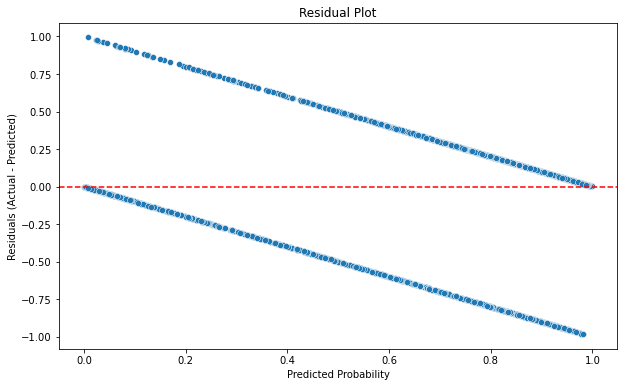

In [20]:
#plotting the residuals
import seaborn as sns
y_prob = model.predict_proba(X_test_transformed)[:,1]
residuals = y_test-y_prob

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_prob, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Probability")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

Here my problem is it is a perfect linear relationship that I am looking for. But my key indicator was the tweet numbers. And may be logistic regression was not a good model for me because it basically states as something increases there is a linear relation; it another thing will increase or decrease. 

What if low and high tweet numbers are the indicators of fake news while middle tweet numbers are real? So I will take a look at it with calibration curve. 

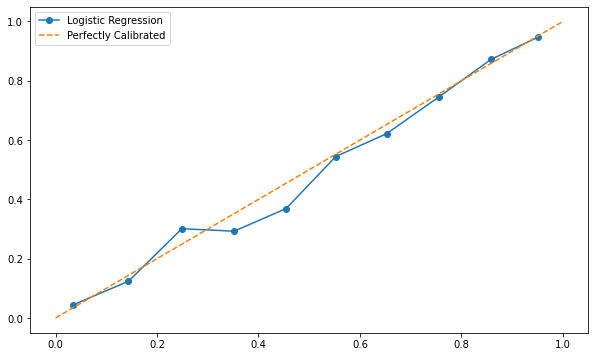

In [21]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10,6))
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.legend()
plt.show()

Again.. My model almost fits perfectly and i was using not the last one I created. So this means that data is fine for LogisticRegression but still I want to try oout RandomForesClassifier. The good thing about data analysis is you can try different things just because you dont think its fine. And there is lots of options, so we will go for another one just to be sure.

## RandomForest

### What is RandomForest?

**RandomForest** is a commonly used machine learning algorithm that uses many decision trees to make better predictions. Decision trees are basically trees that have branches and each branch has been opened by the answer we give to its question. For example there is a start point and its says "Are you woman?", the answer might be yes or no. In this situtaion there would be 2 branches and it goes and goes like this. Its main aim is to find the best split to subset the data. Most of the time this data had been trained through the *Classification and Regression Tree(CART)* algorithm.

Even though **decision trees** are well known and used algorithm, there is some downsides of it which are the problem of overfitting and bias. However, when there is lots of decision trees that forms an ensemble in the random forest algorithm they predict more accurate results due to individual trees are not correlated with each other.

**Ensemble methods** are basically decision trees (classifiers) which are aggregated to identify most common result. The most known **bagging method** is selecting the random sample of data in the training set with replacement, so an individual can be picked again and again. After several samples this models are trained independently and found out that the average majority of the predictions yield accurate estimates than other models. This approach has been used to reduce variance in a noisy dataset.

**RandomForest Algorithm** is an extension of the bagging method. It utilizes both feature randomness and bagging to create an uncorrelated forest of decision trees. *Feature randomness* generates random subsets so the decision trees has low correlation among themselves.

### RandomForestClassifier

Basically RandomForest algorithm creates lots of uncorrelated decision trees. And those decision trees helps us to solve the problem based on its features. Classifier is kind of LogisticRegression. Our output is not a float or a number. Actually its a number which is 0 or 1 may be in cases if there is more than one answer it might increase. But the meaning of those are not the numbers, they are commonlt true/false, real/fake etc..

**How can I interpret my classifier results?**

Yes I have been asking the same question too so I look at multiple places for this answer.

First of all, *feature importance* is key. It measures how much each feature contributes the model's predictions. There are a few ways to calculate feature importance and they are :
 
  1. **Gini Importance(Mean Decrease Impurity)** : It measures how much each feature's contribution to reducing gini 
    impurity or other impurity methods like enthropy in decision trees. *Gini Impurity* is checks how often a randomly
    selected would be mislabeled if it assigned by class probability. On the otherhand *Enthropy* measures uncertainity in 
    a node's class distribution and originates from information theory.Gini is a little bit faster than enthropy 
    because it does not uses logarithmic calculations but this leads to fastly creating splits and favoring dominant 
    classes while enthropy more balanced node partions. As a matter of fact gini is more useful with larger data sets and 
    the enthropy should be used with more balanced data sets. Also gini is more robust than enthropy in probability 
    changes.In addition gini is often comes with libraries like CART but enthropy is more used when we need 
    theoretical information.
    
    
    
  2. **Permutation Importance** : It is a technique that measures a feature's value by decreasing (permutating) its value 
  and sees if the models accuracy decrease based on this feature. If the model accuracy decreases based on this then we can say this feature is an important one. This techniques uses so much of the computer power, so its compututaionally expensive but provides a more accurate measure of feature importance.
  
  
  
  
  3. **SHAP (SHapley Additive exPlanations) Values** : It answers the question of "How do you know why your
  model predicted a certain output?" .Those values provide a way to interpret ML models by assigning each feature an importance value. It is based on Game Theory. The intuition behind SHAP values is simple; SHAP values distribute the predictions around all features fairly and each features contribution is accounted for based on their interactions with other features. It is model agnostic so we can use it with different models like RandomForest or XGBoost. It is again compututionally expensive and needs approximations like TreeSHAP for bigger models.Also strong interactions can complex because SHAP assumes additive contributions.
  
  
There is also individual interpreters. But here is a little hads up before starting to explain them, as we know RandomForest uses an ensemble model so we look at everything, everybranch and tree at once. Here we will not follow this approach and it might be not effective in every situation. Here are the 3 individual interpreters;

  1. **Tree Interpreter** : This method looks at a single data like news and and traces it through the forest. It
  calculates how much each feature changed the probability. It is useful to understanding why a particular predictin was made. So we look at the reasons behind.
  
  
  
  2. **Partial Dependence Plots (PDPs)**: It does not care about the individual behavior. It looks at the average behavior 
  of a single feature along the dataset. This one helps us to understand the marginal effect of the feature on the prediction.
  
  
  3. **Individual Conditional Expectation (ICE) Plots** : It is a different type of PDPs. It does not look at the average
  but shows the line for every single row on your data. It is some kind of asking "What if?" to every data points. It is useful because sometimes the average (a.k.a PDPs) can lie. So this one provides a more granular view of how a feature influences predictions for different instances.
  
  
  
  
### Performance Metrics in RandomForest

We use recall,precision etc.. same with logistic regression but also we look for other things too. Here is some important metrics:

 1. **Confusion Matrix**: It provides a summary of prediction results. There are some key terms like *true positive* which
 means that model said "Real" and it was true. Or here is *true negative* where model said "False" and again it was true. The tricky part is where model said real but it was fake , it is called *false positive*. Other way around where model said it was fake but in reality it was real is *false negative*.
 
 
 2. **ROC Curve** : Receiver Operating Characteristic (ROC) curve shows the true positive rate against false positive rate
 with different treshold settings.It is a plot that shows how the model perform as we change the strictness. A RandomForest decides if a model real or fake by putting it above 0.5 which are 1 and below 0.5 are 0. A perfect model would have curve up into the left corner immediately.
 
 
 3. **AUC Curve** : While ROC is a curve, AUC is the final score. It shows model ability to distinguish different classes.
 It ranges from 0 to 1. We would like to have something like 0.7-0.8 because below this might be acceptable but above this is probably data leakage. AUC is better than accuracy. As you change your treshold accuracy also changes. However, in AUC case model separates two classes regardless of the picked treashold. *It is the best way to compare LogisticRegression and RandomForest*. 
  
    
    
Now its time to do some coding rather than explaining the logic of RandomForest.
    

In [13]:
from sklearn.ensemble import RandomForestClassifier

model_clf = RandomForestClassifier()

model_clf.fit(X_train_transformed,y_train)

RandomForestClassifier()

In [23]:
y_pred4 = model_clf.predict(X_test_transformed)

from sklearn.metrics import confusion_matrix

print(f"Random Forest Accuracy:{accuracy_score(y_test,y_pred4):.2f}")
print("\nClassification Report")
print(classification_report(y_test,y_pred4))

Random Forest Accuracy:0.89

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.65      0.73      1092
           1       0.90      0.96      0.93      3482

    accuracy                           0.89      4574
   macro avg       0.87      0.80      0.83      4574
weighted avg       0.88      0.89      0.88      4574



## Comments

Well here I can see that my new RandomForest model did a great jub because the best model I had with LogisticRegression had 0.83 accuracy. But it also had 0.74 recall but here it is 0.64. So compared to LogisticRegression, RandomForest model can catch 64% of the fake news. I will try to improve this but rather than that its not a bad picture here we have right now.

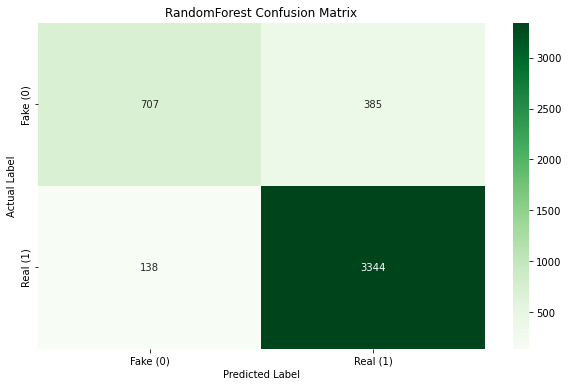

In [24]:
#creating the confusion matrix

cm = confusion_matrix(y_test,y_pred4)

plt.figure(figsize=(10,6))

sns.heatmap(cm,annot=True,fmt="d",cmap="Greens",
           xticklabels=["Fake (0)","Real (1)"],
           yticklabels=["Fake (0)","Real (1)"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("RandomForest Confusion Matrix")
plt.show()

In this Confusion Matrix I can see that my model does a pretty good job while predicting the Real label. But here I have a little problem and it is that my model does its job of capturing real ones it also captures some fake news as reals. We can see that I have 1101 fake news however my model just captured 708 of them which reminded me of the recall score. Here again same problem. 

To solve this problem i will use **predict_proba** function of the RandomForest.

<Figure size 720x432 with 0 Axes>

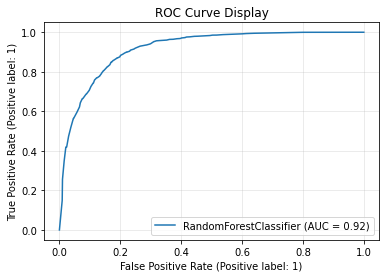

In [25]:
#Roc Curve and AUC Score

from sklearn.metrics import RocCurveDisplay

plt.figure(figsize = (10,6))
RocCurveDisplay.from_estimator(model_clf,X_test_transformed,y_test,)

plt.title("ROC Curve Display")
plt.grid(alpha=0.3)
plt.show()

#this code will calculate AUC automatically

This ROC Curve and AUC Score tells me a story. When I look at the ROC curve its actually something I really would love. My model gradually improves and curves to the top left corner. But the AUC score here is a problem because ist above 0.9. Treshold for good AUC score is around 0.7-0.8 however i have 0.91 which implies that i may have a data leakage here because its so high.

In [26]:
#feature importance
importances = model_clf.feature_importances_
feature_names = preprocessor.get_feature_names_out()

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print(feature_df.sort_values(by='Importance', ascending=False).head(10))

                       Feature  Importance
0    domain_enc__source_domain    0.249779
501      num_scaler__tweet_num    0.127244
339          title_tfidf__pitt    0.012854
60           title_tfidf__brad    0.012120
427           title_tfidf__the    0.011251
22            title_tfidf__and    0.010383
438            title_tfidf__to    0.009524
226        title_tfidf__justin    0.008223
313            title_tfidf__of    0.007913
24        title_tfidf__aniston    0.007801


#### IMPORANT POINT

This was something I was thinking of from the beggining. Domain is the most important part of a website and to determine if a news is fake. But also the number of tweets was important too. Like I said tweet numbers is important because people are tend to write more about fake news.


# Improvement Part

To improve my model i will use class_balance and sample size. But not just this, in the point of prediction i will use predict proba.

In [27]:
# recreating model

model_clf1 = RandomForestClassifier(n_estimators=1000,
                                   class_weight="balanced",
                                   random_state=42)

# fitting the model

model_clf1.fit(X_train_transformed,y_train)

# predicting classes but with probabilities

y_probs = model_clf1.predict_proba(X_test_transformed)[:,1]

custom_treshold = 0.7
y_preds = (y_probs >= custom_treshold).astype(int)
#the code above tells that anything below 0.7 is going to be labeled as fake. 

In [28]:
#after this changes we will look at the confusion matrix to see the improvements
print(f"Random Forest Accuracy:{accuracy_score(y_test,y_preds):.2f}")
print("\nClassification Report")
print(classification_report(y_test,y_preds))

Random Forest Accuracy:0.87

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.80      0.74      1092
           1       0.93      0.89      0.91      3482

    accuracy                           0.87      4574
   macro avg       0.81      0.84      0.83      4574
weighted avg       0.88      0.87      0.87      4574



Here I can see that my recall now is 0.79 which tells me my model can catch the 79% of the fake news. It is a very good improvement. Even though the accuracy decreased by 1 percentile point it is still close to perfect report.

<Figure size 720x432 with 0 Axes>

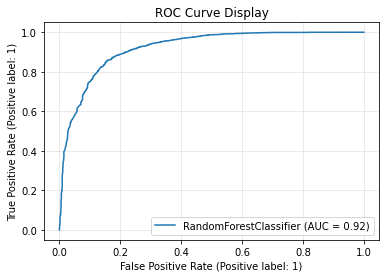

In [29]:
plt.figure(figsize = (10,6))
RocCurveDisplay.from_estimator(model_clf1,X_test_transformed,y_test,)

plt.title("ROC Curve Display")
plt.grid(alpha=0.3)
plt.show()


### !!!

Here my AUC increased to 0.92, i dont want this because it is shows that I have data leakage. I think my model does not do lots of predicting but it blacklists some of the domains because domain it the most important feature. So for that matter i will drop this feature and also the tweet number to see what will happen to AUC score. If it drops to 0.7 levels and accuracy is smth like 0.8 then i can say that my model improved.

Even though accuracy has been decreased a lot more than I have ever expected, still I will go with AUC score because it is the one that differenatiate Logistic Regression and RandomForest.

In [30]:
## splitting the data from the beginning
y = df["real"]

X1 = df.drop(columns=(["real","source_domain"]),axis =1)

X_train1,X_test1,y_train1,y_test1 = train_test_split(X1,y,test_size = 0.2)

#creating new preprocessor

preprocessor2 = ColumnTransformer(
            transformers = [
                ("title_tfidf",TfidfVectorizer(max_features=500),"title"),
                ("num_scaler",StandardScaler(),["tweet_num"])
            ])

X_train_trnsfrm_RF = preprocessor2.fit_transform(X_train1,y_train1)
X_test_trnsfrm_RF = preprocessor2.transform(X_test1)


#fitting model

model_clf1.fit(X_train_trnsfrm_RF,y_train1)

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=42)

In [31]:
##prediction phase

y_probs_rf = model_clf1.predict_proba(X_test_trnsfrm_RF)[:,1]

y_preds1 =(y_probs_rf >= 0.7).astype(int)

In [32]:
#classification report
print(f"Random Forest Accuracy:{accuracy_score(y_test1,y_preds1):.2f}")
print("\nClassification Report")
print(classification_report(y_test1,y_preds1))

Random Forest Accuracy:0.84

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.77      0.70      1112
           1       0.92      0.86      0.89      3462

    accuracy                           0.84      4574
   macro avg       0.78      0.82      0.79      4574
weighted avg       0.85      0.84      0.84      4574



<Figure size 720x432 with 0 Axes>

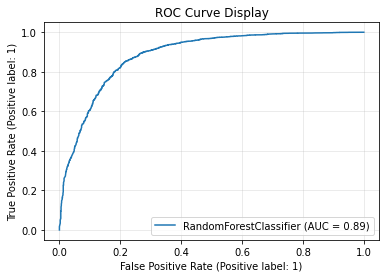

In [33]:
#ROC Curve and AUC Score

plt.figure(figsize = (10,6))
RocCurveDisplay.from_estimator(model_clf1,X_test_trnsfrm_RF,y_test1,)

plt.title("ROC Curve Display")
plt.grid(alpha=0.3)
plt.show()


In [34]:
#blind test feature importances

importances = model_clf1.feature_importances_
feature_names = preprocessor2.get_feature_names_out()

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
print(feature_df.sort_values(by='Importance', ascending=False).head(10))

                   Feature  Importance
500  num_scaler__tweet_num    0.219388
428       title_tfidf__the    0.018174
439        title_tfidf__to    0.013517
22        title_tfidf__and    0.012465
61       title_tfidf__brad    0.011687
451     title_tfidf__trump    0.011314
336      title_tfidf__pitt    0.010634
310        title_tfidf__of    0.010022
199        title_tfidf__in    0.009458
212  title_tfidf__jennifer    0.009190


I have a good accuracy and recall but the problem is I still have high AUC which is 0.88. I need something around 0.8 or even 0.7. So I will drop tweet_num too.After that I will look at some words then take a look at the feature importances and put max_depth = 5, so i will constraint the trees.

In [35]:
y = df["real"]

X2 = df.drop(columns=(["real","source_domain","tweet_num"]),axis =1)

X_train2,X_test2,y_train2,y_test2 = train_test_split(X2,y,test_size = 0.2)

#creating new preprocessor

preprocessor3 = ColumnTransformer(
            transformers = [
                ("title_tfidf",TfidfVectorizer(max_features=500),"title")
                
            ])

X_train_trnsfrm_RF1 = preprocessor3.fit_transform(X_train2,y_train2)
X_test_trnsfrm_RF1 = preprocessor3.transform(X_test2)


#fitting model

model_clf1.fit(X_train_trnsfrm_RF1,y_train2)

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=42)

<Figure size 720x432 with 0 Axes>

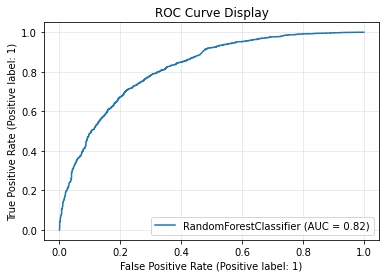

In [36]:
#ROC Curve and AUC Score

#this time i will just look at this to see if AUC score changed

plt.figure(figsize = (10,6))
RocCurveDisplay.from_estimator(model_clf1,X_test_trnsfrm_RF1,y_test2,)

plt.title("ROC Curve Display")
plt.grid(alpha=0.3)
plt.show()


## THIS WAS THE THING I WAS WAITING FOR !!

I need 0.8 AUC or somethig close to it so my model is godd not just picking some of the fake or real news to the blacklist to function. Now my model is learning whats going on rather than mimicking the behaviors of the fake news. Now I need to take a look at the accuracy score too.

In [37]:
y_probs_rf1 = model_clf1.predict_proba(X_test_trnsfrm_RF1)[:,1]

y_preds2 =(y_probs_rf >= 0.7).astype(int)

In [38]:
#classification report
print(f"Random Forest Accuracy:{accuracy_score(y_test2,y_preds2):.2f}")
print("\nClassification Report")
print(classification_report(y_test2,y_preds2))

Random Forest Accuracy:0.61

Classification Report
              precision    recall  f1-score   support

           0       0.24      0.30      0.26      1079
           1       0.76      0.70      0.73      3495

    accuracy                           0.61      4574
   macro avg       0.50      0.50      0.50      4574
weighted avg       0.64      0.61      0.62      4574



But after I dropped one of the most important features of my data has all I have is a accuracy of 0.61 and recall is 0.29 so my model only catchs 29% of the fake news. 

So I will try tu save this by giving model exact tweet number, I will group them.

In [25]:
# --- STEP 1: Feature Engineering (Create the columns first!) ---
# Create the bins
df['tweet_bin'] = pd.qcut(df['tweet_num'], q=4, labels=['Low', 'Medium', 'High', 'Viral'])

# Create linguistic features
df['all_caps_count'] = df['title'].apply(lambda x: sum(1 for word in x.split() if word.isupper() and len(word) > 2))
df['punctuation_count'] = df['title'].apply(lambda x: x.count('!') + x.count('?'))
df['title_len'] = df['title'].apply(len)

# --- STEP 2: Prepare Data ---
y = df["real"]
# Make sure to drop 'real' but KEEP your new features in X
X = df.drop(columns=["real"]) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 3: Define Preprocessor (Now it can find the columns) ---
from sklearn.preprocessing import OrdinalEncoder

preprocessor4 = ColumnTransformer(transformers=[
    ("domain_enc", TargetEncoder(), ["source_domain"]),
    ("title_tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=1000, stop_words="english"), "title"),
    # Use OrdinalEncoder for bins because they are categories ('Low', 'Medium'...)
    ("bin_enc", OrdinalEncoder(), ["tweet_bin"]), 
    # Scale your new numerical features
    ("num_scaler", StandardScaler(), ["all_caps_count", "punctuation_count", "title_len"])
])

# --- STEP 4: Transform and Fit ---
X_train_transform2 = preprocessor4.fit_transform(X_train, y_train)
X_test_trasform2 = preprocessor4.transform(X_test)

model_clf.fit(X_train_transform2, y_train)

RandomForestClassifier()

In [22]:
from sklearn.metrics import accuracy_score,classification_report,RocCurveDisplay

In [20]:
y_probs2 = model_clf.predict_proba(X_test_trasform2)[:,1]

y_preds2 =(y_probs2 >= 0.7).astype(int)

print(f"Random Forest Accuracy:{accuracy_score(y_test,y_preds2):.2f}")
print("\nClassification Report")
print(classification_report(y_test,y_preds2))

Random Forest Accuracy:0.84

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.75      0.69      1131
           1       0.91      0.87      0.89      3509

    accuracy                           0.84      4640
   macro avg       0.78      0.81      0.79      4640
weighted avg       0.85      0.84      0.84      4640



<Figure size 720x432 with 0 Axes>

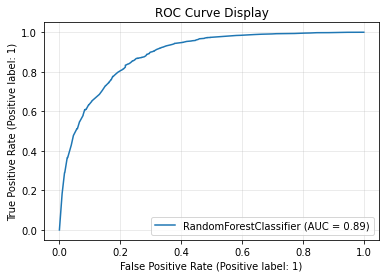

In [23]:
plt.figure(figsize = (10,6))
RocCurveDisplay.from_estimator(model_clf,X_test_trasform2,y_test,)

plt.title("ROC Curve Display")
plt.grid(alpha=0.3)
plt.show()


After all those careful calculations and coding, I think RandomForest is not good for this dataset. I know that there is so many ways to use it and its a really good model but the problem is about the dataset. This dataset is not good for lots of branches and trees. It was good to solve with LogisticRegression because it wasn't a complicated one. Anything I was doing all those hours was just complicate things to get a better score but the scores I get with LogisticRegression was quite good. So this was a good lesson to me. 

Here above, I got the same result as I did before. Again AUC is smth like 0.89 but accuracy is good. So I will do just one attempt. If it does not works then I wont go further. By the way this isn't the way I am. If I want something I would go to at least the end of it. For now I will stop because there is no results that it does deserves my efforts.

In [26]:
# --- STEP 1: Feature Engineering (STAYS THE SAME) ---
df['tweet_bin'] = pd.qcut(df['tweet_num'], q=4, labels=['Low', 'Medium', 'High', 'Viral'])
df['all_caps_count'] = df['title'].apply(lambda x: sum(1 for word in x.split() if word.isupper() and len(word) > 2))
df['punctuation_count'] = df['title'].apply(lambda x: x.count('!') + x.count('?'))
df['title_len'] = df['title'].apply(len)

# --- STEP 2: Prepare Data ---
y = df["real"]
# We keep everything in X for now so the preprocessor can find the columns it needs
X1 = df.drop(columns=["real"]) 

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y, test_size=0.2, random_state=42)

# --- STEP 3: Define "Blind" Preprocessor ---
# NOTICE: We removed "domain_enc" and we never added "tweet_num" here.
preprocessor_blind = ColumnTransformer(transformers=[
    ("title_tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=1000, stop_words="english"), "title"),
    ("bin_enc", OrdinalEncoder(), ["tweet_bin"]), 
    ("num_scaler", StandardScaler(), ["all_caps_count", "punctuation_count", "title_len"])
])

# --- STEP 4: Transform and Fit ---
# The preprocessor will ONLY grab the columns listed above and ignore the rest (like tweet_num and source_domain)
X_train_transform1 = preprocessor_blind.fit_transform(X_train1, y_train1)
X_test_transform1 = preprocessor_blind.transform(X_test1)

model_clf.fit(X_train_transform1, y_train1)

RandomForestClassifier()

In [28]:
y_probs3 = model_clf.predict_proba(X_test_transform1)[:,1]

y_preds3 =(y_probs3 >= 0.7).astype(int)

print(f"Random Forest Accuracy:{accuracy_score(y_test1,y_preds3):.2f}")
print("\nClassification Report")
print(classification_report(y_test1,y_preds3))

Random Forest Accuracy:0.79

Classification Report
              precision    recall  f1-score   support

           0       0.55      0.73      0.63      1131
           1       0.90      0.81      0.85      3509

    accuracy                           0.79      4640
   macro avg       0.73      0.77      0.74      4640
weighted avg       0.82      0.79      0.80      4640



<Figure size 720x432 with 0 Axes>

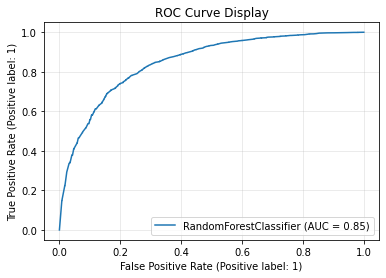

In [30]:
plt.figure(figsize = (10,6))
RocCurveDisplay.from_estimator(model_clf,X_test_transform1,y_test1,)

plt.title("ROC Curve Display")
plt.grid(alpha=0.3)
plt.show()


My last worked now.. See this is what life is like. You will have to try so much to get what you want and you should be not giving up. I tried hard to finish this project like really long hours and I did while working a full time service job. This is the way we humans are. There is nothing we cant accomplish if we want really bad. I am doing this stuff to get better and o what I want sincerely like 2-3 years. I will go whenever I want and be super rich in 1 to 2 years from now. 

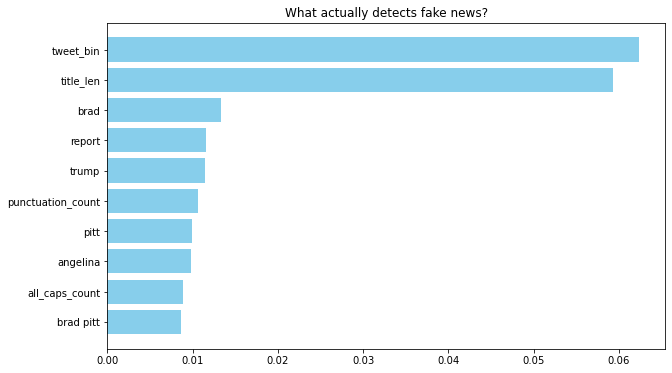

In [32]:

import matplotlib.pyplot as plt

#get the feature names
tfidf_features = preprocessor_blind.named_transformers_['title_tfidf'].get_feature_names_out()
all_features = list(tfidf_features) + ['tweet_bin', 'all_caps_count', 'punctuation_count', 'title_len']

#importances
importances = model_clf.feature_importances_

#creating the dataframe
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
top_10 = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

#plotting part
plt.figure(figsize=(10, 6))
plt.barh(top_10['Feature'], top_10['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("What actually detects fake news?")
plt.show()

# GRAND FINALE : CONCLUSIONS

### So whats the point, what happened?

So at the beggining our point was to use LogisticRegression to find out whats happening in our fake news data set, how could my model predict fake news and stuff. We have tried to use different parameters and enchance our work with also using the preprocessors to find out more with the data we have. 

We always take a look at important metrics like accuracy score, classification report, confusion matrix and feature importances. With those metrics we can rank our models from best to worst.

Then I thought why not using trees?? Because as you know we could have find better reaults and we can create better models; models that are not just "blacklisters" but models that can actually find out about thfake news. 

Of course we had rough times because it wasn't easy to fit a right and good model. Also this dataset had been used with LogisticRegression and it wasn't a proper one for the RandomForestClassifier. However, I handled this situation with dropping some important columns like title and domain. Because those columns were actually the reason for the data leakage. As I look at the model metrics like ROC Curve and AUC Score in RandomForest I saw that all models had AUc score above or around 0.90 which was a really red flag. Only model that had acceptable AUC Score had accuracy and recall very low that it was basically useless.

So what did I do? Well I think of giving up every minute because I wasn't believeing in myself and I think this trait has been going on like over 6 months. I had lost my self-belief but with this project I realized life can always turn around and I could have find beautiful things at the edge of giving up. 

Finally, as I said I dropped most importand and also leakER columns but I created other columns in X with preprocessor. To find out the fake news the best way is to look at the tweet number but not just as a number ; it hould be like bins. Low,middle, high bins of tweet numbers are way much useful than just numbers because here I am trying to find an answer to a question : Is this news fake or real? Then I also created a different column to find out if a title consist of all caps or does it have punctuations or even it has a very long title. Those are also basically the most important features of fake news.

**AND MY FINAL MODEL WORKED!!!!**

My final RandomForest model has an accuracy of 0.79 which is pretty good but not just that, its AUC Score is 085 so I do not have data leakage and my model is smart to understand fake and real news. Also I took a look at the what actually detects the fake news and the first thing was the tweet bins. After that title length was important. Another stuff that interested me, news that has "brad" "pitt" or "angelina" in their title was tend to be fake. It was another way to say that most of the magasin news were actually not true. 

So my concluson here is I did a pretty good job and I am very proud of myself. I would have used my LogisticRegression model but I had pushed my limits to find something better. I think this is way much important to create a project.